In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from google.colab import drive
drive.mount("/content/gdrive")

# Buscar el archivo automáticamente en todo Drive
import os
for root, dirs, files in os.walk("/content/gdrive/MyDrive"):
    for file in files:
        if "RT_IOT" in file:
            print(os.path.join(root, file))

Mounted at /content/gdrive
/content/gdrive/MyDrive/ia/RT_IOT2022
/content/gdrive/MyDrive/sis420/RT_IOT2022


In [4]:
data = pd.read_csv("/content/gdrive/MyDrive/ia/RT_IOT2022")
print(data.shape)
data.head()

(123117, 85)


,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [5]:
print(data.columns.tolist())

['Unnamed: 0', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.to

In [6]:
data = data.drop(columns=["Unnamed: 0"])
data = data.drop_duplicates()

for col in data.select_dtypes(include="object").columns:
    data[col] = pd.Categorical(data[col]).codes

print("Valores nulos:", data.isnull().sum().sum())
data.info()

Valores nulos: 0
<class 'pandas.core.frame.DataFrame'>
Index: 117922 entries, 0 to 123116
Data columns (total 84 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id.orig_p                 117922 non-null  int64  
 1   id.resp_p                 117922 non-null  int64  
 2   proto                     117922 non-null  int8   
 3   service                   117922 non-null  int8   
 4   flow_duration             117922 non-null  float64
 5   fwd_pkts_tot              117922 non-null  int64  
 6   bwd_pkts_tot              117922 non-null  int64  
 7   fwd_data_pkts_tot         117922 non-null  int64  
 8   bwd_data_pkts_tot         117922 non-null  int64  
 9   fwd_pkts_per_sec          117922 non-null  float64
 10  bwd_pkts_per_sec          117922 non-null  float64
 11  flow_pkts_per_sec         117922 non-null  float64
 12  down_up_ratio             117922 non-null  float64
 13  fwd_header_size_tot       117922

In [7]:
X = data.drop("Attack_type", axis=1).values
y = data["Attack_type"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (117922, 83)
y shape: (117922,)


In [8]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)
print("Media:", mu)
print("Desviación estándar:", sigma)

Media: [3.49490943e+04 1.05081227e+03 1.10398399e+00 6.30823765e-01
 3.80847365e+00 2.29020878e+00 1.94277573e+00 1.47050593e+00
 8.47594172e-01 3.51060695e+05 3.51014377e+05 7.02075072e+05
 8.55130781e-01 5.47869609e+01 1.97792778e+01 2.06693577e+01
 4.75989213e+01 1.77247672e+01 1.84813351e+01 1.17306355e-01
 9.50111090e-01 7.97162531e-01 3.60399247e-01 4.05403572e-01
 2.73085599e+00 1.70112447e-02 0.00000000e+00 9.92181272e-04
 6.69934363e-04 9.56994878e+01 1.20977443e+02 2.23031377e+02
 1.00102327e+02 8.35833481e+00 3.83934296e+00 5.36711640e+01
 5.34237038e+02 1.92777804e+01 2.10564411e+01 1.33873069e+01
 1.49269644e+02 7.57268415e+02 6.49368281e+01 7.62084012e+01
 9.18919117e+03 1.79502811e+06 3.77788481e+06 2.47054515e+05
 6.02075667e+05 3.85393690e+03 4.23399649e+05 1.76983530e+06
 9.05053421e+04 1.53089241e+05 4.41737454e+03 1.79971924e+06
 3.80949976e+06 1.45321693e+05 4.69201058e+05 4.09127288e+07
 1.56493256e+00 1.35068292e+00 1.37267842e+02 2.25997222e+02
 2.00979840e+01 1

In [9]:
y_binario = (y > 0).astype(int)
print("Distribución de clases:")
print(pd.Series(y_binario).value_counts())

Distribución de clases:
1    110297
0      7625
Name: count, dtype: int64


In [10]:
m = y_binario.size
X_final = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print("X_final shape:", X_final.shape)

X_final shape: (117922, 84)


In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [12]:
def computeCost(X, y, theta):
    m = len(y)
    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J = (-1/m) * (y.dot(np.log(h)) + (1 - y).dot(np.log(1 - h)))
    return J

In [13]:
def gradientDescent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        h = sigmoid(X.dot(theta))
        errors = h - y
        theta = theta - (alpha / m) * (X.T.dot(errors))
        cost_history.append(computeCost(X, y, theta))

    return theta, cost_history

In [14]:
theta = np.zeros(X_final.shape[1])
alpha = 0.01
iterations = 1000

theta, cost_history = gradientDescent(X_final, y_binario, theta, alpha, iterations)

print("Theta final:", theta)
print("Costo final:", computeCost(X_final, y_binario, theta))

Theta final: [ 1.91528502e+00 -4.70261343e-03  9.31091662e-02 -2.49056355e-01
 -1.32824093e-01  1.76477991e-02 -1.25647758e-02 -8.44354525e-03
 -8.50595067e-03 -8.42636441e-04 -2.27906323e-03 -2.14000224e-03
 -2.20953708e-03  5.16192982e-02 -2.92827957e-02  1.00899607e-01
  1.05356572e-01 -4.11233244e-03  7.04425499e-02  4.44803575e-02
  1.57172042e-02  1.45432007e-01  1.20386381e-01 -3.72786857e-02
 -1.82087078e-02 -1.02857340e-02  1.13189538e-02  0.00000000e+00
  4.08100628e-02  3.77693336e-02  6.55612566e-02 -1.24068213e-01
 -2.53800639e-02 -2.19109086e-02 -1.41366313e-01 -1.91852200e-01
 -5.55495346e-02  1.66419990e-03 -4.39710123e-02 -5.66515866e-03
  3.23846088e-02 -5.91324176e-02 -1.15068779e-03 -2.98428399e-02
 -3.39036526e-02 -7.89192004e-03 -9.85900637e-03  1.75391994e-02
 -1.44266116e-02 -3.39578354e-03 -1.43372808e-02 -1.03199307e-01
  9.39386710e-03 -7.32891569e-02 -7.90042390e-02  3.62017360e-03
 -8.04966495e-03  1.76372388e-02 -6.76547487e-03 -3.30361558e-03
 -1.95992773

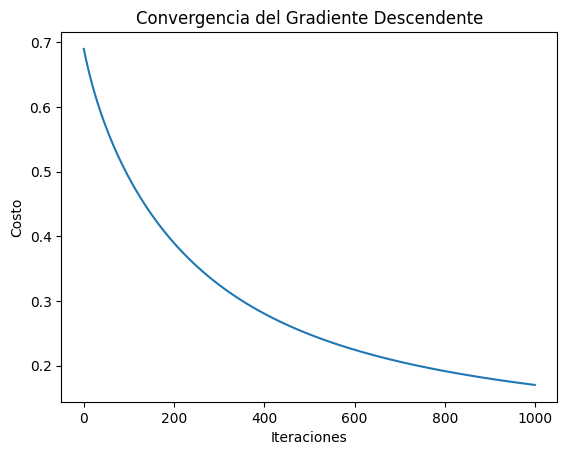

In [15]:
plt.plot(cost_history)
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("Convergencia del Gradiente Descendente")
plt.show()

In [16]:
predicciones = (sigmoid(X_final.dot(theta)) >= 0.5).astype(int)
precision = np.mean(predicciones == y_binario) * 100
print(f"Precisión del modelo: {precision:.2f}%")

Precisión del modelo: 94.08%


Costo final Regresión Lineal: 0.013680940835392579


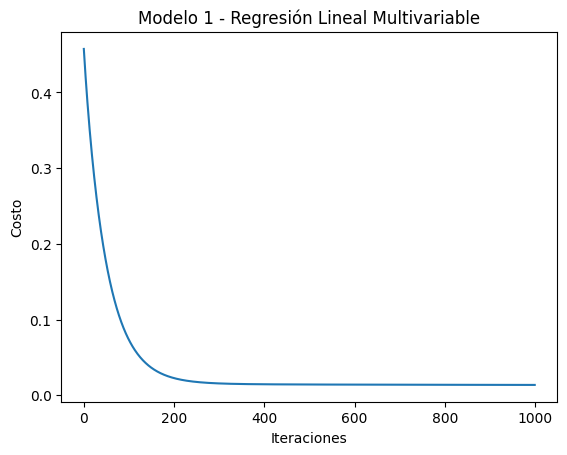

In [17]:
# MODELO 1: Regresión Lineal Multivariable
def computeCostLineal(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    J = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return J

def gradientDescentLineal(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []
    for i in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        theta = theta - (alpha / m) * (X.T.dot(errors))
        cost_history.append(computeCostLineal(X, y, theta))
    return theta, cost_history

theta_lineal = np.zeros(X_final.shape[1])
alpha = 0.01
iterations = 1000

theta_lineal, cost_history_lineal = gradientDescentLineal(X_final, y_binario, theta_lineal, alpha, iterations)

print("Costo final Regresión Lineal:", computeCostLineal(X_final, y_binario, theta_lineal))

plt.plot(cost_history_lineal)
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("Modelo 1 - Regresión Lineal Multivariable")
plt.show()

Costo final Regresión Polinómica: 0.012642660009412941


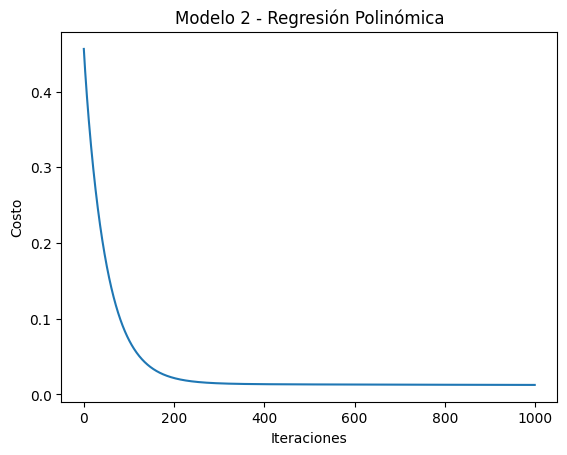

In [18]:
# MODELO 2: Regresión Polinómica (grado 2)
def mapPolyFeatures(X, degree=2):
    X_poly = X.copy()
    for d in range(2, degree + 1):
        X_poly = np.concatenate([X_poly, X ** d], axis=1)
    return X_poly

# Crear características polinómicas
X_poly = mapPolyFeatures(X_norm, degree=2)
X_poly_final = np.concatenate([np.ones((m, 1)), X_poly], axis=1)

# Normalizar las nuevas características
X_poly_norm = X_poly_final.copy()
mu_poly = np.mean(X_poly_final[:, 1:], axis=0)
sigma_poly = np.std(X_poly_final[:, 1:], axis=0)
sigma_poly[sigma_poly == 0] = 1
X_poly_norm[:, 1:] = (X_poly_final[:, 1:] - mu_poly) / sigma_poly

theta_poly = np.zeros(X_poly_norm.shape[1])

theta_poly, cost_history_poly = gradientDescentLineal(X_poly_norm, y_binario, theta_poly, alpha, iterations)

print("Costo final Regresión Polinómica:", computeCostLineal(X_poly_norm, y_binario, theta_poly))

plt.plot(cost_history_poly)
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("Modelo 2 - Regresión Polinómica")
plt.show()

Costo final Ecuación Normal: 0.012094067213983645


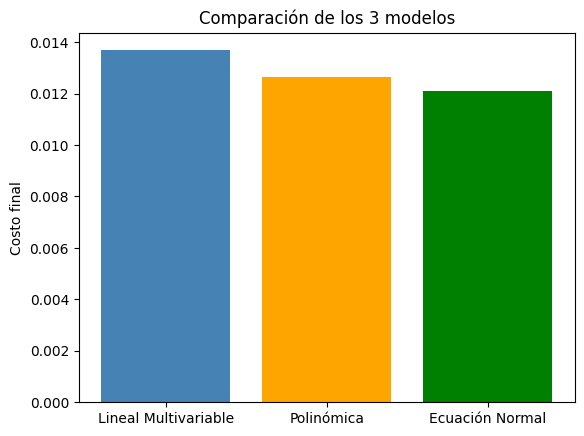

In [19]:
# MODELO 3: Ecuación Normal
# theta = (X^T * X)^-1 * X^T * y

def ecuacionNormal(X, y):
    theta = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

theta_normal = ecuacionNormal(X_final, y_binario)

costo_normal = computeCostLineal(X_final, y_binario, theta_normal)
print("Costo final Ecuación Normal:", costo_normal)

# La ecuación normal no tiene historial de costo porque no itera
# Graficamos la comparación de los 3 modelos
costos = [cost_history_lineal[-1], cost_history_poly[-1], costo_normal]
modelos = ['Lineal Multivariable', 'Polinómica', 'Ecuación Normal']

plt.bar(modelos, costos, color=['steelblue', 'orange', 'green'])
plt.ylabel("Costo final")
plt.title("Comparación de los 3 modelos")
plt.show()

In [20]:
# 100 PREDICCIONES con los 3 modelos
np.random.seed(42)
indices_pred = np.random.choice(len(y_binario), 100, replace=False)

X_pred = X_final[indices_pred]
X_pred_poly = X_poly_norm[indices_pred]
y_real = y_binario[indices_pred]

# Predicciones con cada modelo
pred_lineal = (sigmoid(X_pred.dot(theta_lineal)) >= 0.5).astype(int)
pred_poly = (sigmoid(X_pred_poly.dot(theta_poly)) >= 0.5).astype(int)
pred_normal = (sigmoid(X_pred.dot(theta_normal)) >= 0.5).astype(int)

# Precisión de cada modelo
prec_lineal = np.mean(pred_lineal == y_real) * 100
prec_poly = np.mean(pred_poly == y_real) * 100
prec_normal = np.mean(pred_normal == y_real) * 100

print("=== 100 PREDICCIONES ===")
print(f"Precisión Regresión Lineal:    {prec_lineal:.2f}%")
print(f"Precisión Regresión Polinómica: {prec_poly:.2f}%")
print(f"Precisión Ecuación Normal:      {prec_normal:.2f}%")

# Mostrar tabla de predicciones
print("\nMuestra de 10 predicciones:")
print(f"{'#':<5}{'Real':<10}{'Lineal':<10}{'Polinómica':<12}{'Normal':<10}")
print("-" * 40)
for i in range(10):
    print(f"{i+1:<5}{y_real[i]:<10}{pred_lineal[i]:<10}{pred_poly[i]:<12}{pred_normal[i]:<10}")

=== 100 PREDICCIONES ===
Precisión Regresión Lineal:    93.00%
Precisión Regresión Polinómica: 94.00%
Precisión Ecuación Normal:      94.00%

Muestra de 10 predicciones:
#    Real      Lineal    Polinómica  Normal    
----------------------------------------
1    1         1         1           1         
2    0         1         1           1         
3    1         1         1           1         
4    1         1         1           1         
5    1         1         1           1         
6    1         1         1           1         
7    1         1         1           1         
8    1         1         1           1         
9    1         1         1           1         
10   1         1         1           1         


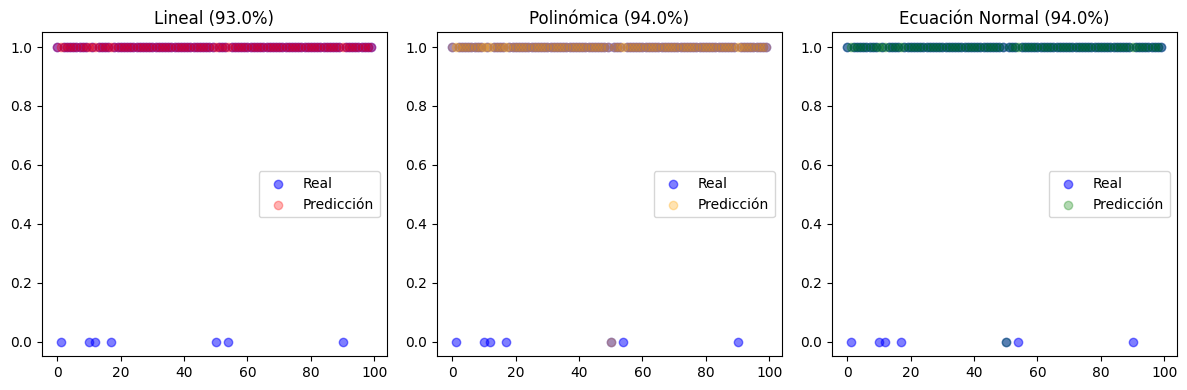

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(range(100), y_real, color='blue', alpha=0.5, label='Real')
plt.scatter(range(100), pred_lineal, color='red', alpha=0.3, label='Predicción')
plt.title(f'Lineal ({prec_lineal:.1f}%)')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(range(100), y_real, color='blue', alpha=0.5, label='Real')
plt.scatter(range(100), pred_poly, color='orange', alpha=0.3, label='Predicción')
plt.title(f'Polinómica ({prec_poly:.1f}%)')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(range(100), y_real, color='blue', alpha=0.5, label='Real')
plt.scatter(range(100), pred_normal, color='green', alpha=0.3, label='Predicción')
plt.title(f'Ecuación Normal ({prec_normal:.1f}%)')
plt.legend()

plt.tight_layout()
plt.show()